<a href="https://colab.research.google.com/github/May-o-nnaise/CPSMA-4313-MS/blob/main/RecreatingTheMasters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()
# Replace 'your_file.xlsx' with the actual name of the file you uploaded
df = pd.read_excel(io.BytesIO(uploaded['RetailPrices.xlsx']))

Saving WholesalePrices.xlsx to WholesalePrices.xlsx


KeyError: 'RetailPrices.xlsx'

In [22]:
df = pd.read_excel('RetailPrices.xlsx', sheet_name='Sheet1')
df.head(13)

,Unnamed: 0,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,Jan,2.328,1.599,1.769,1.554,1.461,1.466,1.929,4.823,2.522,4.953,2.577
1,Feb,2.267,1.464,1.755,1.557,1.449,1.597,2.005,4.211,2.996,5.897,2.500
2,Mar,2.081,1.404,1.831,1.544,1.525,1.625,2.046,3.446,2.992,6.227,NaN
3,Apr,1.793,1.409,2.081,1.463,2.019,1.620,2.520,3.270,2.864,5.122,NaN
4,May,1.684,1.414,1.987,1.362,1.640,1.625,2.863,2.666,2.699,4.548,NaN
5,Jun,1.491,1.332,1.628,1.203,1.554,1.642,2.707,2.219,2.715,3.775,NaN
6,Jul,1.546,1.333,1.725,1.243,1.401,1.642,2.936,2.094,3.080,3.599,NaN
7,Aug,1.455,1.367,1.622,1.219,1.328,1.709,3.116,2.043,3.204,3.587,NaN
8,Sep,1.471,1.422,1.651,1.383,1.353,1.835,2.902,2.065,3.821,3.488,NaN
9,Oct,1.390,1.540,1.660,1.282,1.408,1.821,3.419,2.072,3.370,NaN,NaN


In [30]:
df1 = pd.read_excel('WholesalePrices.xlsx', sheet_name='Sheet1')
df1.head(13)

,commodity_desc,year_id,month_id,month_desc,amount_cents,amount_fixed
0,Eggs,2000,1,January,68.13,0.6813
1,Eggs,2000,2,February,71.39,0.7139
2,Eggs,2000,3,March,64.70,0.6470
3,Eggs,2000,4,April,73.13,0.7313
4,Eggs,2000,5,May,58.52,0.5852
5,Eggs,2000,6,June,66.50,0.6650
6,Eggs,2000,7,July,62.22,0.6222
7,Eggs,2000,8,August,75.32,0.7532
8,Eggs,2000,9,September,68.85,0.6885
9,Eggs,2000,10,October,76.82,0.7682


In [34]:
df2 = pd.read_csv('EggLossesHPAI.csv')
df2.head(13)

,Confirmed Diagnosis,Birds Affected
0,3/17/2026,0.9M
1,3/10/2026,1.5M
2,3/6/2026,0.2M
3,2/27/2026,3.3M
4,2/27/2026,1.2M
5,2/18/2026,1.5M
6,2/17/2026,0.1M
7,2/17/2026,2.6M
8,2/11/2026,0.1M
9,2/3/2026,0.7M


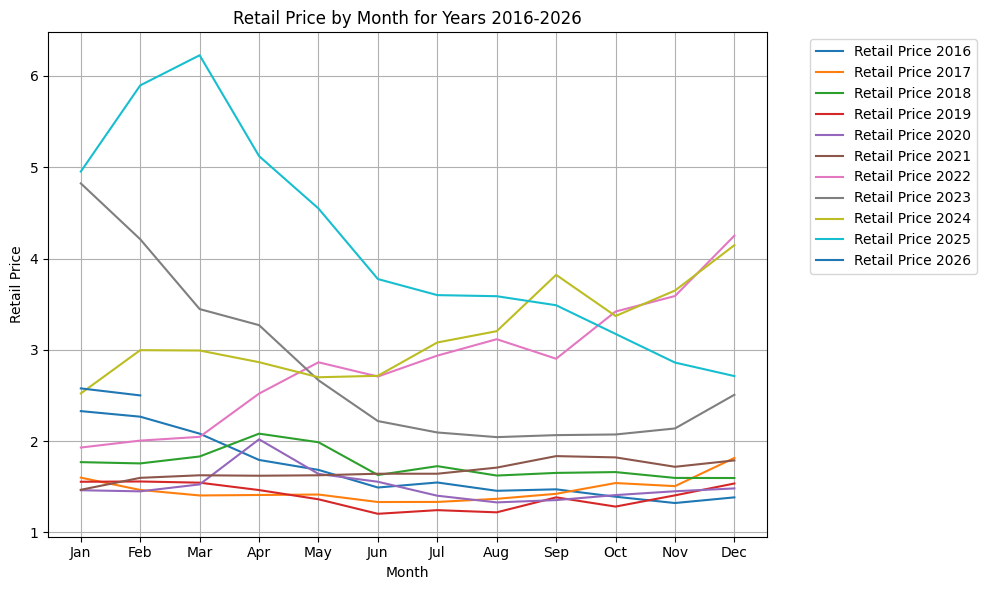

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# Re-read the DataFrame to ensure correct column names with explicit header
df = pd.read_excel('RetailPrices.xlsx', sheet_name='Sheet1', header=0)

# Convert all column names to string type and then strip whitespace
df.columns = df.columns.astype(str).str.strip()

# Identify year columns (assuming they are numeric and greater than 2000 for this dataset)
year_columns = [col for col in df.columns if col.isdigit() and int(col) >= 2000]

plt.figure(figsize=(10, 6))
for year in year_columns:
    # Drop rows where the year's price is NaN to avoid breaking the plot
    plot_df = df.dropna(subset=[year])
    plt.plot(plot_df['Unnamed: 0'], plot_df[year], label=f'Retail Price {year}')

plt.xlabel('Month')
plt.ylabel('Retail Price')
plt.title('Retail Price by Month for Years ' + year_columns[0] + '-' + year_columns[-1])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

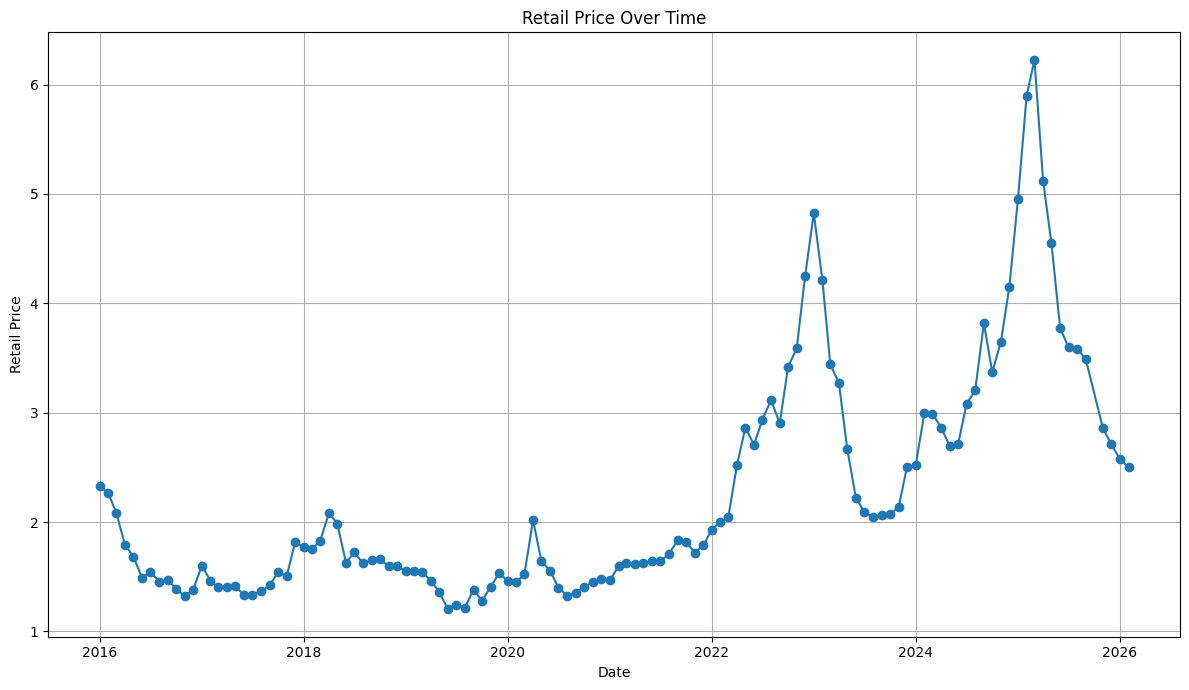

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Re-read the DataFrame to ensure correct column names with explicit header
df = pd.read_excel('RetailPrices.xlsx', sheet_name='Sheet1', header=0)

# Convert all column names to string type and then strip whitespace
df.columns = df.columns.astype(str).str.strip()

# Identify year columns (assuming they are numeric and greater than 2000 for this dataset)
year_columns = [col for col in df.columns if col.isdigit() and int(col) >= 2000]

# Melt the DataFrame to transform year columns into rows, creating a 'Year' column
df_melted = df.melt(id_vars=['Unnamed: 0'], value_vars=year_columns, var_name='Year', value_name='Retail Price')

# Map month abbreviations to numerical values for sorting
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_melted['Month_Num'] = df_melted['Unnamed: 0'].map(month_mapping)

# Create a 'Date' column by combining 'Year' and 'Month_Num'
# Filter out rows where 'Retail Price' is NaN to avoid plotting gaps
df_melted = df_melted.dropna(subset=['Retail Price'])
df_melted['Date'] = pd.to_datetime(df_melted['Year'] + '-' + df_melted['Month_Num'].astype(str) + '-01')

# Sort the DataFrame by the new 'Date' column
df_melted = df_melted.sort_values(by='Date')

plt.figure(figsize=(12, 7))
plt.plot(df_melted['Date'], df_melted['Retail Price'], marker='o', linestyle='-')

plt.xlabel('Date')
plt.ylabel('Retail Price')
plt.title('Retail Price Over Time')
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

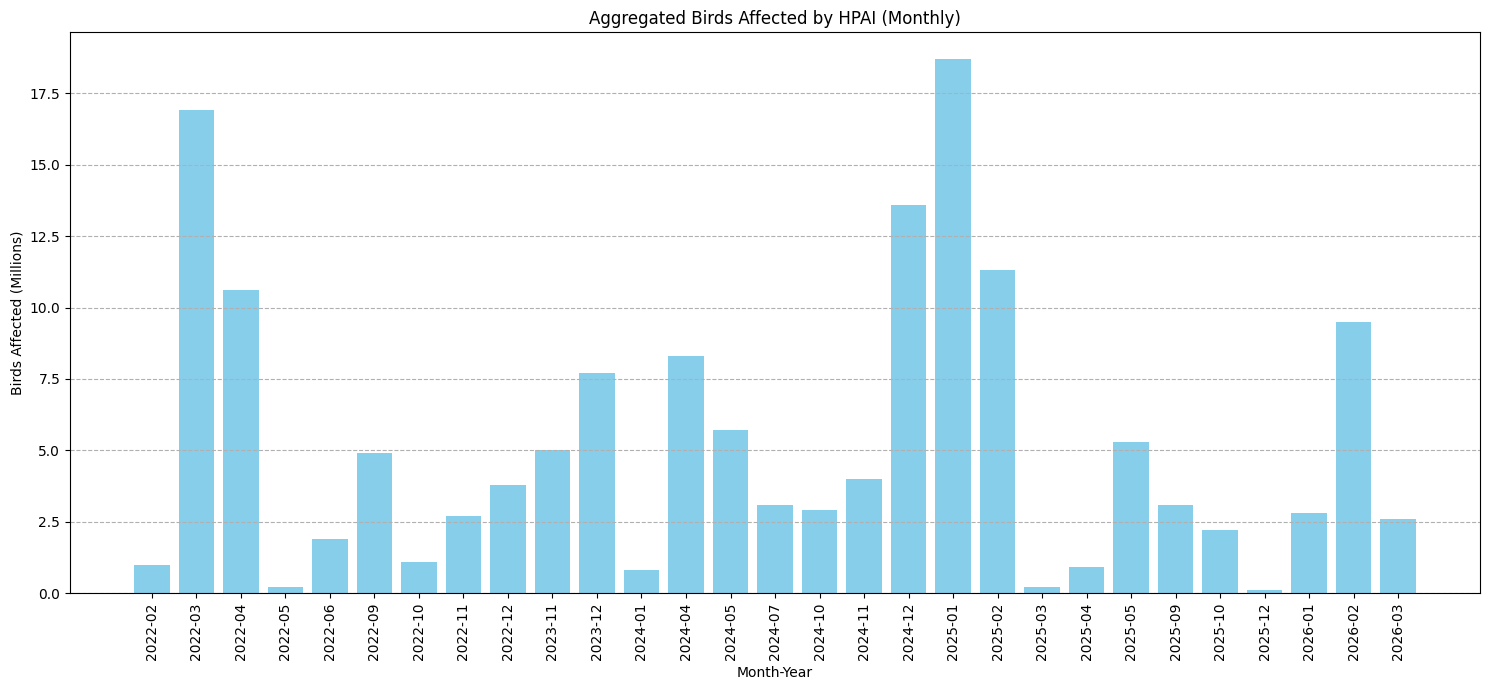

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df2 is loaded (it should be from previous steps)
# df2 = pd.read_csv('EggLossesHPAI.csv') # Uncomment if df2 is not in kernel state

# Convert 'Birds Affected' to numeric (millions)
def convert_to_millions(value):
    if isinstance(value, str) and 'M' in value:
        return float(value.replace('M', ''))
    return float(value)

df2['Birds Affected (Millions)'] = df2['Birds Affected'].apply(convert_to_millions)

# Convert 'Confirmed Diagnosis' to datetime
df2['Confirmed Diagnosis'] = pd.to_datetime(df2['Confirmed Diagnosis'])

# Extract Year and Month for aggregation
df2['YearMonth'] = df2['Confirmed Diagnosis'].dt.to_period('M')

# Aggregate 'Birds Affected' by YearMonth
monthly_losses = df2.groupby('YearMonth')['Birds Affected (Millions)'].sum().reset_index()
monthly_losses['YearMonth'] = monthly_losses['YearMonth'].astype(str) # Convert back to string for plotting

# Sort by date for better visualization if needed, but grouping already implies order
monthly_losses = monthly_losses.sort_values(by='YearMonth')

plt.figure(figsize=(15, 7))
plt.bar(monthly_losses['YearMonth'], monthly_losses['Birds Affected (Millions)'], color='skyblue')
plt.xlabel('Month-Year')
plt.ylabel('Birds Affected (Millions)')
plt.title('Aggregated Birds Affected by HPAI (Monthly)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

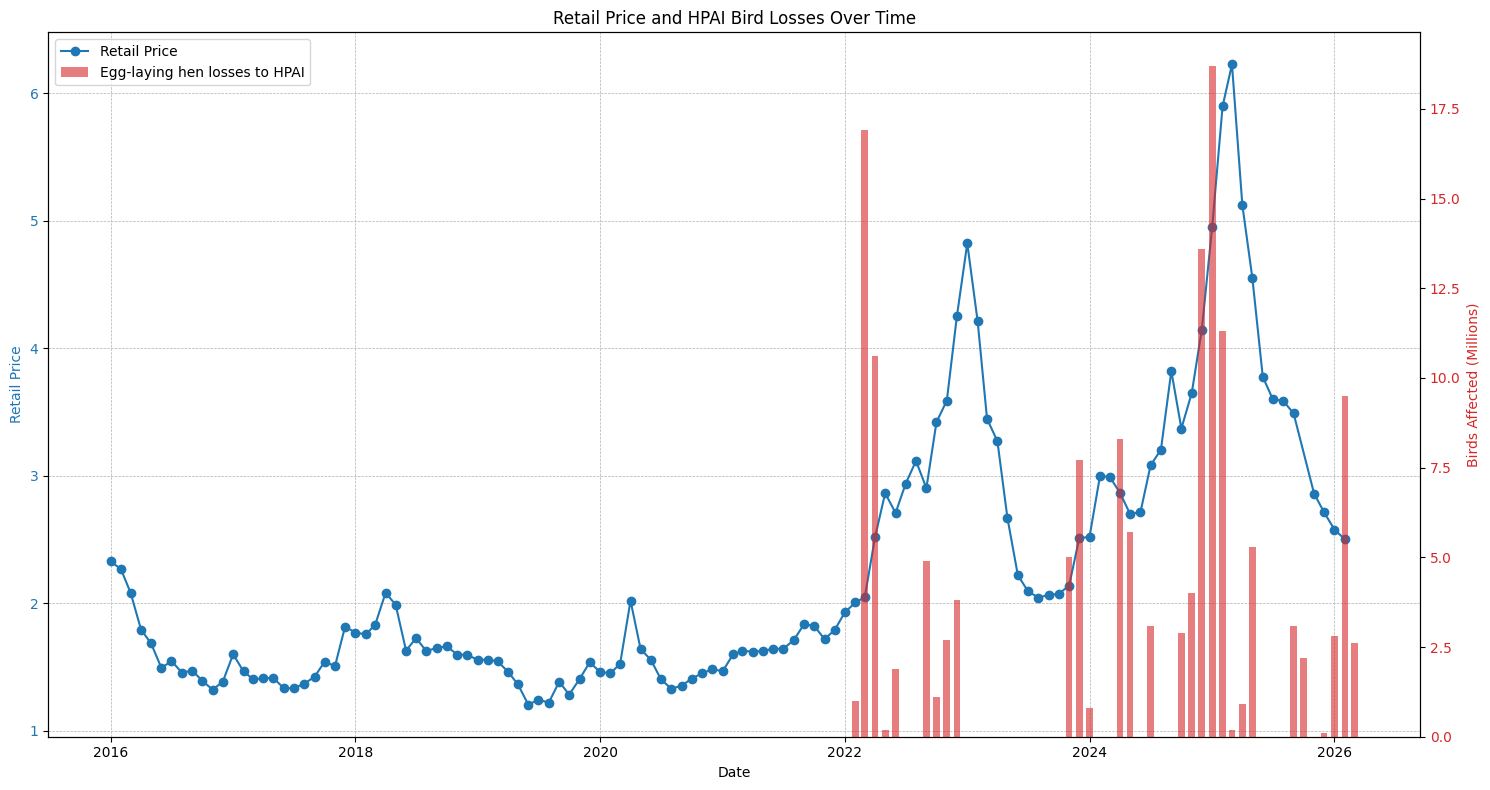

In [150]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Prepare Retail Price data (from wdTXdYMPq5uX) ---
# Re-read the DataFrame to ensure correct column names with explicit header
df = pd.read_excel('RetailPrices.xlsx', sheet_name='Sheet1', header=0)

# Convert all column names to string type and then strip whitespace
df.columns = df.columns.astype(str).str.strip()

# Identify year columns
year_columns = [col for col in df.columns if col.isdigit() and int(col) >= 2000]

# Melt the DataFrame
df_melted = df.melt(id_vars=['Unnamed: 0'], value_vars=year_columns, var_name='Year', value_name='Retail Price')

# Map month abbreviations to numerical values for sorting
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_melted['Month_Num'] = df_melted['Unnamed: 0'].map(month_mapping)

# Create a 'Date' column and sort
df_melted = df_melted.dropna(subset=['Retail Price'])
df_melted['Date'] = pd.to_datetime(df_melted['Year'] + '-' + df_melted['Month_Num'].astype(str) + '-01')
df_melted = df_melted.sort_values(by='Date')

# --- Prepare HPAI Egg Losses data (from RJcPJZPzsXtQ) ---
# Ensure df2 is loaded and processed
def convert_to_millions(value):
    if isinstance(value, str) and 'M' in value:
        return float(value.replace('M', ''))
    return float(value)

df2['Birds Affected (Millions)'] = df2['Birds Affected'].apply(convert_to_millions)
df2['Confirmed Diagnosis'] = pd.to_datetime(df2['Confirmed Diagnosis'])

# Extract Year and Month for aggregation
df2['YearMonth'] = df2['Confirmed Diagnosis'].dt.to_period('M')

# Aggregate 'Birds Affected' by YearMonth
monthly_losses = df2.groupby('YearMonth')['Birds Affected (Millions)'].sum().reset_index()
# Convert YearMonth to datetime for consistent plotting with df_melted['Date']
monthly_losses['Date'] = monthly_losses['YearMonth'].dt.to_timestamp()
monthly_losses = monthly_losses.sort_values(by='Date')

# --- Create combined plot ---
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot Retail Price on primary y-axis (ax1)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Retail Price', color=color)
ax1.plot(df_melted['Date'], df_melted['Retail Price'], color=color, label='Retail Price', marker='o', linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Birds Affected (Millions)', color=color)  # we already handled the x-label with ax1
ax2.bar(monthly_losses['Date'], monthly_losses['Birds Affected (Millions)'], color=color, label='Egg-laying hen losses to HPAI', alpha=0.6, width=20) # Adjust width as needed
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Retail Price and HPAI Bird Losses Over Time')
fig.tight_layout()  # otherwise the right y-label is slightly clipped

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

/tmp/ipykernel_1082/231108075.py:151: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(lines1 + labels2, labels1 + labels2, loc='upper left')


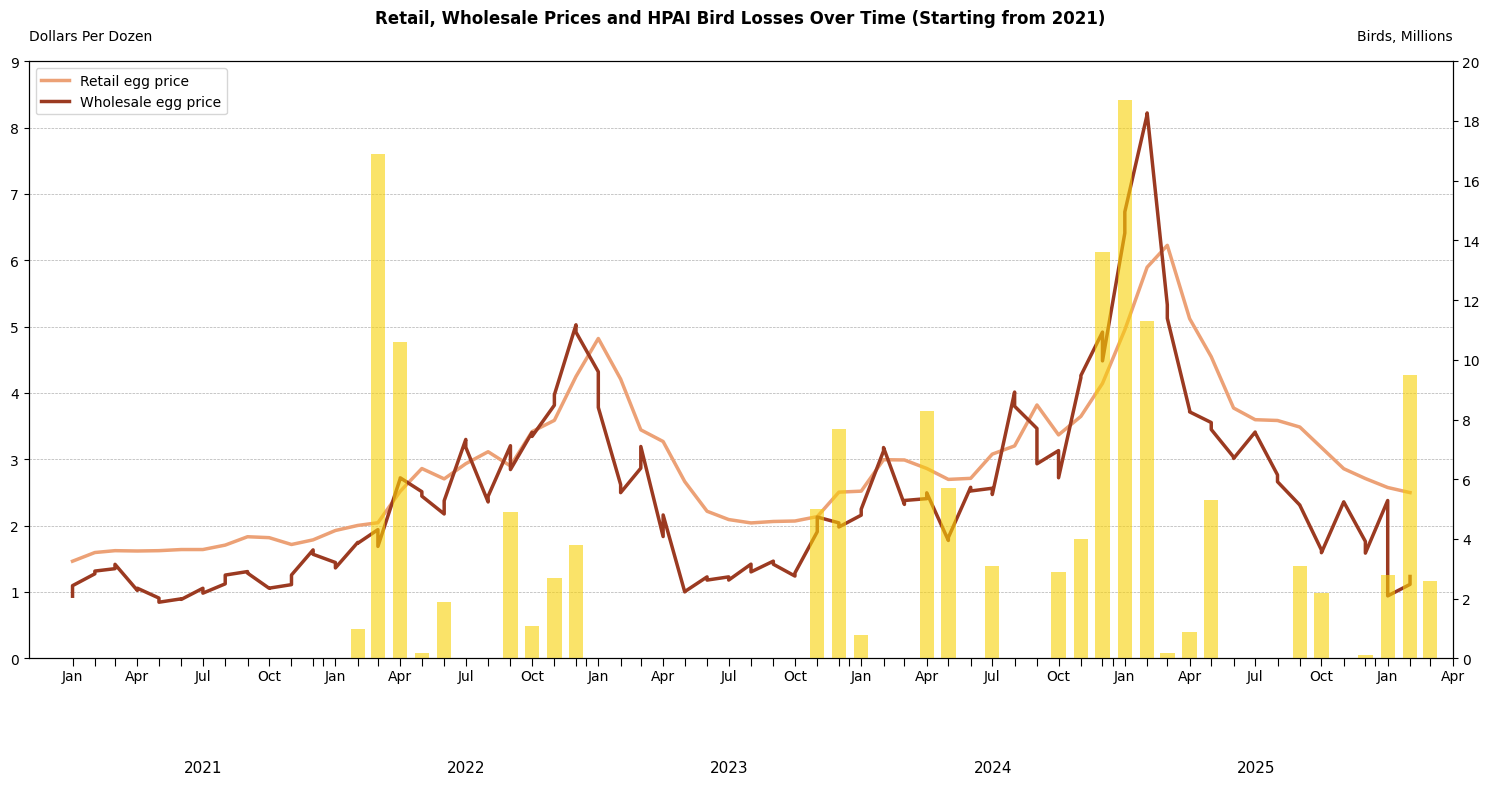

In [293]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# --- Prepare Retail Price data ---
df = pd.read_excel('RetailPrices.xlsx', sheet_name='Sheet1', header=0)
df.columns = df.columns.astype(str).str.strip()
year_columns = [col for col in df.columns if col.isdigit() and int(col) >= 2000]

df_melted = df.melt(id_vars=['Unnamed: 0'], value_vars=year_columns, var_name='Year', value_name='Retail Price')
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_melted['Month_Num'] = df_melted['Unnamed: 0'].map(month_mapping)
df_melted = df_melted.dropna(subset=['Retail Price'])
df_melted['Date'] = pd.to_datetime(df_melted['Year'] + '-' + df_melted['Month_Num'].astype(str) + '-01')
df_melted = df_melted.sort_values(by='Date')
# Filter retail price data to start from 2021
df_melted = df_melted[df_melted['Date'].dt.year >= 2021].copy()

# --- Prepare Wholesale Price data ---
df1 = pd.read_excel('WholesalePrices.xlsx', sheet_name='Sheet1')
# Filter for 'Eggs' if there are other commodities
df1_eggs = df1[df1['commodity_desc'] == 'Eggs'].copy()
df1_eggs['Date'] = pd.to_datetime(df1_eggs['year_id'].astype(str) + '-' + df1_eggs['month_id'].astype(str) + '-01')
df1_eggs = df1_eggs.sort_values(by='Date')
# Filter df1_eggs to start from 2021 to match retail price data
df1_eggs = df1_eggs[df1_eggs['Date'].dt.year >= 2021].copy()

# --- Prepare HPAI Egg Losses data ---
def convert_to_millions(value):
    if isinstance(value, str) and 'M' in value:
        return float(value.replace('M', ''))
    return float(value)

df2['Birds Affected (Millions)'] = df2['Birds Affected'].apply(convert_to_millions)
df2['Confirmed Diagnosis'] = pd.to_datetime(df2['Confirmed Diagnosis'])
df2['YearMonth'] = df2['Confirmed Diagnosis'].dt.to_period('M')
monthly_losses = df2.groupby('YearMonth')['Birds Affected (Millions)'].sum().reset_index()
monthly_losses['Date'] = monthly_losses['YearMonth'].dt.to_timestamp()
monthly_losses = monthly_losses.sort_values(by='Date')
# Filter HPAI losses data to start from 2021
monthly_losses = monthly_losses[monthly_losses['Date'].dt.year >= 2021].copy()

# --- Create combined plot ---
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot Retail Price on primary y-axis (ax1)
color_retail = '#ECA176'
ax1.set_xlabel('') # Remove default x-axis label
ax1.plot(df_melted['Date'], df_melted['Retail Price'], color=color_retail, label='Retail egg price', marker='', linestyle='-', linewidth=2.5)

# Plot Wholesale Price on primary y-axis (ax1)
color_wholesale = '#9B3A21'
ax1.plot(df1_eggs['Date'], df1_eggs['amount_fixed'], color=color_wholesale, label='Wholesale egg price', linestyle='-', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)

# Set y-axis limits and ticks for the left y-axis (Retail/Wholesale Prices)
ax1.set_ylim(0, 9)
ax1.set_yticks(range(0, 10, 1))

# Use ax.text for precise positioning of the left y-axis label
ax1.text(0, 1.03, 'Dollars Per Dozen', color='black', ha='left', va='bottom', rotation='horizontal', transform=ax1.transAxes)

# Instantiate a second axes that shares the same x-axis for HPAI losses
ax2 = ax1.twinx()
color_hpai = '#F8D106'
ax2.bar(monthly_losses['Date'], monthly_losses['Birds Affected (Millions)'], color=color_hpai, label='Egg-laying hen losses to HPAI', alpha=0.6, width=20)
ax2.tick_params(axis='y', labelcolor='black')

# Set y-axis limits for the right y-axis (HPAI Losses)
ax2.set_ylim(0, 20)
ax2.set_yticks(range(0, 21, 2))

# Use ax.text for precise positioning of the right y-axis label
ax2.text(1, 1.03, 'Birds, Millions', color='black', ha='right', va='bottom', rotation='horizontal', transform=ax2.transAxes)

# --- X-axis customization for monthly labels only ---

# Create explicit ticks for every month
min_date_val = pd.Timestamp('2021-01-01')
max_date_val = pd.Timestamp('2026-04-01')

# Generate all month start dates
month_start_ticks = pd.date_range(start=min_date_val, end=max_date_val, freq='MS')

# Generate all year end dates (December 31st)
year_end_ticks = []
for year in range(min_date_val.year, max_date_val.year + 1):
    dec_31_date = pd.Timestamp(f'{year}-12-15')
    if dec_31_date < max_date_val: # Only add if it's before the plot's max date
        year_end_ticks.append(dec_31_date)

# Combine and sort all tick locations
all_x_ticks = sorted(list(set(month_start_ticks).union(set(year_end_ticks))))

# Create labels for combined ticks
all_x_tick_labels = []
for d in all_x_ticks:
    if d.month == 1 and d.day == 1:
        all_x_tick_labels.append('Jan')
    elif d.month == 12 and d.day == 31:
        all_x_tick_labels.append('') # No label for Dec 31st, just a tick
    elif d.month in [4, 7, 10] and d.day == 1:
        all_x_tick_labels.append(d.strftime('%b'))
    else:
        all_x_tick_labels.append('')

ax1.set_xticks(all_x_ticks)
ax1.set_xticklabels(all_x_tick_labels)

# Explicitly ensure tick marks are visible for the x-axis, and revert to normal length/color
ax1.tick_params(axis='x', which='both', bottom=True, length=6, pad=2, labelcolor='black', labelsize=10, labelrotation=0, direction='out') # 'out' for ticks pointing outwards

# The following block that styled the Jan 1st and Dec 31st ticks specifically has been removed.
# These ticks will now follow the general styling defined above.

# Remove any minor tick configurations, as we only want one level of ticks.
ax1.tick_params(axis='x', which='minor', length=0, pad=0, labelcolor='none') # Explicitly hide minor ticks

# Add year labels manually below the month ticks
year_to_plot = sorted(df_melted['Date'].dt.year.unique())
for year in year_to_plot:
    if year == 2026: # Skip 2026
        continue
    # Calculate the midpoint of the year for positioning the label
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end = pd.Timestamp(f'{year}-12-31')
    year_midpoint = year_start + (year_end - year_start) / 2

    # Place the year label slightly below the month labels
    ax1.text(year_midpoint, -0.17, str(year),
             ha='center', va='top', fontsize=11, color='black',
             transform=ax1.get_xaxis_transform()) # Use get_xaxis_transform for relative y-position

# Set x-axis limits to start at 2021-01-01 and end at 2026-04-01
ax1.set_xlim(pd.Timestamp('2020-11-01'), pd.Timestamp('2026-04-01')) # Extended start date

# Add a small margin to ensure ticks are not clipped
plt.margins(x=0.01)

# Title and layout
plt.title('Retail, Wholesale Prices and HPAI Bird Losses Over Time (Starting from 2021)', y=1.05, fontweight='bold')
fig.tight_layout() # Keeping tight_layout as it was in the version the user liked

# Combine legends from all axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + labels2, labels1 + labels2, loc='upper left')

plt.show()

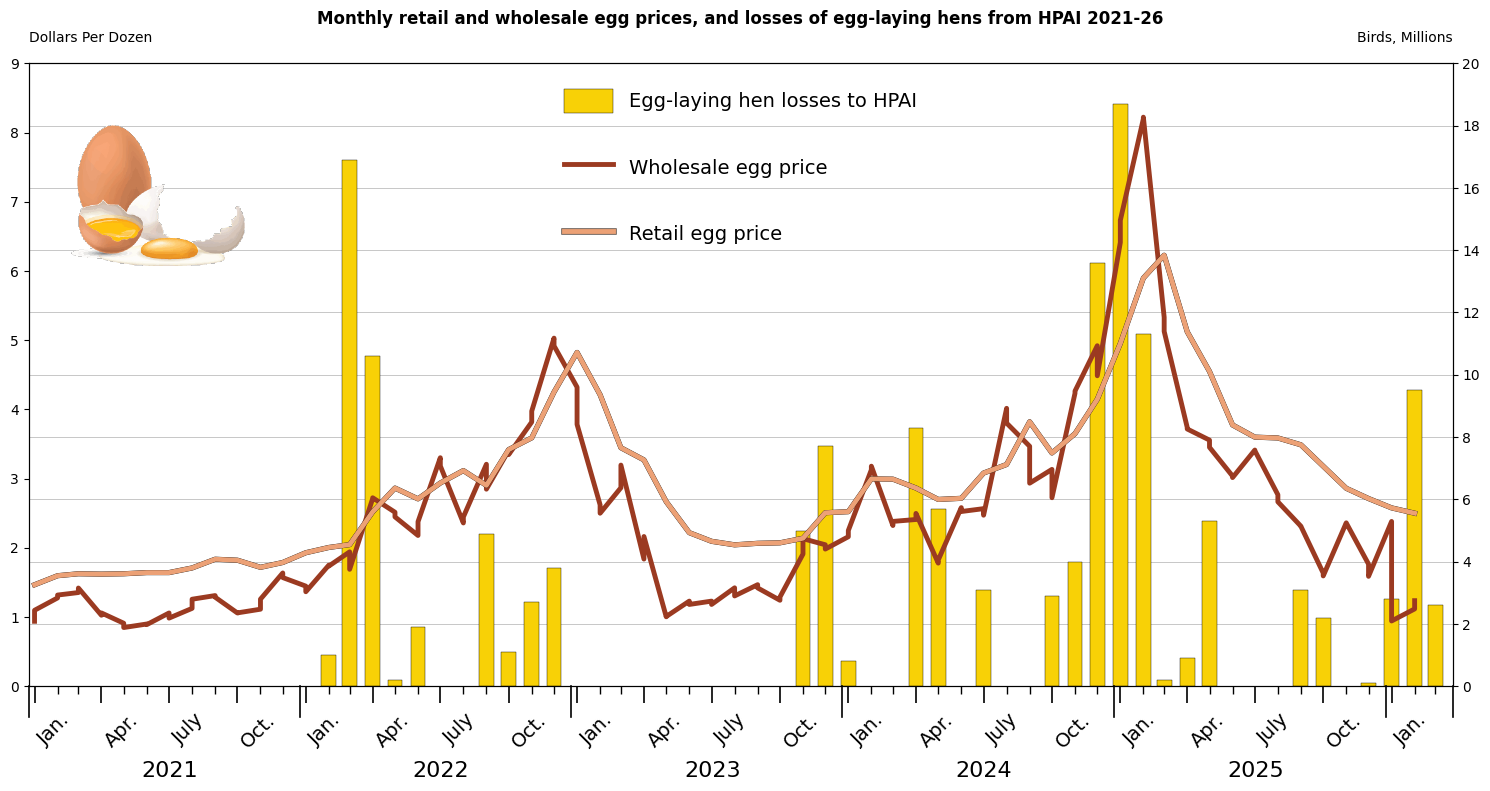

In [311]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from matplotlib.ticker import MultipleLocator

# --- Prepare Retail Price data ---
df = pd.read_excel('RetailPrices.xlsx', sheet_name='Sheet1', header=0)
df.columns = df.columns.astype(str).str.strip()
year_columns = [col for col in df.columns if col.isdigit() and int(col) >= 2000]

df_melted = df.melt(id_vars=['Unnamed: 0'], value_vars=year_columns, var_name='Year', value_name='Retail Price')
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_melted['Month_Num'] = df_melted['Unnamed: 0'].map(month_mapping)
df_melted = df_melted.dropna(subset=['Retail Price'])
df_melted['Date'] = pd.to_datetime(df_melted['Year'] + '-' + df_melted['Month_Num'].astype(str) + '-01')
df_melted = df_melted.sort_values(by='Date')
df_melted = df_melted[df_melted['Date'].dt.year >= 2021].copy()

# --- Prepare Wholesale Price data ---
df1 = pd.read_excel('WholesalePrices.xlsx', sheet_name='Sheet1')
df1_eggs = df1[df1['commodity_desc'] == 'Eggs'].copy()
df1_eggs['Date'] = pd.to_datetime(df1_eggs['year_id'].astype(str) + '-' + df1_eggs['month_id'].astype(str) + '-01')
df1_eggs = df1_eggs.sort_values(by='Date')
df1_eggs = df1_eggs[df1_eggs['Date'].dt.year >= 2021].copy()

# --- Prepare HPAI Egg Losses data ---
def convert_to_millions(value):
    if isinstance(value, str) and 'M' in value:
        return float(value.replace('M', ''))
    return float(value)

df2['Birds Affected (Millions)'] = df2['Birds Affected'].apply(convert_to_millions)
df2['Confirmed Diagnosis'] = pd.to_datetime(df2['Confirmed Diagnosis'])
df2['YearMonth'] = df2['Confirmed Diagnosis'].dt.to_period('M')
monthly_losses = df2.groupby('YearMonth')['Birds Affected (Millions)'].sum().reset_index()
monthly_losses['Date'] = monthly_losses['YearMonth'].dt.to_timestamp()
monthly_losses = monthly_losses.sort_values(by='Date')
monthly_losses = monthly_losses[monthly_losses['Date'].dt.year >= 2021].copy()

# --- Create combined plot ---
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- ax2 first, then raise ax1 above it ---
ax2 = ax1.twinx()
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# Gridlines at zorder=0 — very back, behind everything including bars
ax2.set_axisbelow(True)
ax2.grid(True, which='both', axis='y', linestyle='-', linewidth=0.5, zorder=0)

# Dark red wholesale line — thinner, middle layer (zorder=1)
color_wholesale = '#9B3A21'
ax1.plot(df1_eggs['Date'], df1_eggs['amount_fixed'], color=color_wholesale, label='Wholesale egg price', linestyle='-', linewidth=3.5, zorder=1)

# Black outline for retail price line (zorder lower than actual retail line)
ax1.plot(df_melted['Date'], df_melted['Retail Price'], color='black', linewidth=3.7, zorder=1.9) # Slightly thicker than 3.5
# Pink retail line — thicker, very front (zorder=2)
color_retail = '#ECA176'
ax1.plot(df_melted['Date'], df_melted['Retail Price'], color=color_retail, label='Retail egg price', marker='', linestyle='-', linewidth=3.5, zorder=2)

# Yellow bars on ax2 (highest zorder=3 to be on top)
color_hpai = '#F8D106'
ax2.bar(monthly_losses['Date'], monthly_losses['Birds Affected (Millions)'], color=color_hpai, label='Egg-laying hen losses to HPAI', width=20, zorder=3, edgecolor='black', linewidth=0.3)
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 20)
ax2.set_yticks(range(0, 21, 2))
ax2.text(1, 1.03, 'Birds, Millions', color='black', ha='right', va='bottom', rotation='horizontal', transform=ax2.transAxes)

ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 9)
ax1.set_yticks(range(0, 10, 1))
ax1.text(0, 1.03, 'Dollars Per Dozen', color='black', ha='left', va='bottom', rotation='horizontal', transform=ax1.transAxes)

plt.margins(x=0.01)

# --- X-axis customization ---
min_date_val = pd.Timestamp('2021-01-01')
max_date_val = pd.Timestamp('2026-04-01')

all_months = pd.date_range(start=min_date_val, end=max_date_val, freq='MS')

major_ticks = [d for d in all_months if d.month in [1, 4, 7, 10]]
minor_ticks = [d for d in all_months if d not in major_ticks]

ax1.set_xticks(major_ticks)
ax1.set_xticks(minor_ticks, minor=True)

# Labels
labels = []
for d in major_ticks:
    if d.month == 1:
        labels.append('Jan.')
    elif d.month == 4:
        labels.append('Apr.')
    elif d.month == 7:
        labels.append('July')
    elif d.month == 10:
        labels.append('Oct.')

ax1.set_xticklabels(labels)

# Tick styling
ax1.tick_params(axis='x', which='major',
                length=6, width=1.2,
                labelsize=14, rotation=45,
                direction='out')

ax1.tick_params(axis='x', which='minor',
                length=12, width=1,
                labelbottom=False,
                direction='out')


for label in ax1.get_xticklabels():
    label.set_ha('left')


# Set default labelsize for all ticks
ax1.tick_params(axis='x', which='both', bottom=True, length=12, pad=5,
                labelcolor='black', labelsize=10, labelrotation=0, direction='out')
ax1.tick_params(axis='x', which='minor', length=6, pad=0, labelcolor='none')

# Iterate through labels to adjust size for specific months
for label in ax1.get_xticklabels():
    if label.get_text() in ['Jan.', 'Apr.', 'July', 'Oct.']:
        label.set_fontsize(14) # Set a larger font size for these specific labels
    label.set_rotation(45)
    label.set_ha('left')
    label.set_position((label.get_position()[0] + 0.01, label.get_position()[1]))

# --- Separator lines ---
offset_days = 8
tick_height = 0.05

for year in range(2021, 2027):
    jan1 = pd.Timestamp(f'{year}-01-01')
    sep_x = jan1 - pd.Timedelta(days=offset_days)
    ax1.axvline(x=sep_x, color='black', linewidth=1.2,
                ymin=-tick_height, ymax=0, clip_on=False)

end_sep_x = pd.Timestamp('2026-04-01') - pd.Timedelta(days=offset_days)
ax1.axvline(x=end_sep_x, color='black', linewidth=1.2,
            ymin=-tick_height, ymax=0, clip_on=False)

# --- Year labels ---
year_to_plot = sorted(df_melted['Date'].dt.year.unique())
for year in year_to_plot:
    if year == 2026:
        continue
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end = pd.Timestamp(f'{year}-12-31')
    year_midpoint = year_start + (year_end - year_start) / 2
    ax1.text(year_midpoint, -0.12, str(year),
             ha='center', va='top', fontsize=16, color='black',
             transform=ax1.get_xaxis_transform())

left_edge  = pd.Timestamp('2021-01-01') - pd.Timedelta(days=offset_days)
right_edge = pd.Timestamp('2026-04-01') - pd.Timedelta(days=offset_days)
ax1.set_xlim(left_edge, right_edge)

# --- Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# The black outline for retail price doesn't have a label, so it won't be in lines1. We only want the actual retail line.
# Filter lines1 to only include the wholesale line and the primary retail line (which now has a label).
filtered_lines1 = [line for line, label in zip(lines1, labels1) if label in ['Wholesale egg price', 'Retail egg price']]
filtered_labels1 = ['Wholesale egg price', 'Retail egg price']

all_handles = lines2 + filtered_lines1
all_labels  = labels2 + filtered_labels1

leg = ax1.legend(all_handles, all_labels,
                 loc='center',
                 bbox_to_anchor=(0.5, 0.8333),
                 framealpha=0,
                 edgecolor='none',
                 fontsize=14,
                 handlelength=2.5,
                 handleheight=1.5,
                 borderpad=0,
                 labelspacing=2.2)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

legend_texts = leg.get_texts()
legend_handles = leg.legend_handles

target_y_axes = [8.5/9, 7.5/9, 6.5/9]

for i, (txt, handle) in enumerate(zip(legend_texts, legend_handles)):
    target_display = ax1.transAxes.transform((0, target_y_axes[i]))
    current_display = txt.get_window_extent(renderer)
    pos = txt.get_position()
    current_axes = ax1.transAxes.inverted().transform(
        (current_display.x0, current_display.y0 + current_display.height / 2)
    )
    dy = target_y_axes[i] - current_axes[1]
    txt.set_position((pos[0], pos[1] + dy))

# --- outline retail legend line ---
for handle, label in zip(leg.legend_handles, all_labels):
    if label == 'Retail egg price':
        handle.set_path_effects([
            pe.Stroke(linewidth=4.69, foreground='#5D4F47'),
            pe.Normal()
        ])

# --- Egg image ---
egg_img = mpimg.imread('Untitled.png')
imagebox = OffsetImage(egg_img, zoom=0.45)
ab = AnnotationBbox(
    imagebox,
    xy=(0.03, 0.90),
    xycoords='axes fraction',
    box_alignment=(0, 1),
    pad=0,
    frameon=False
)
ax1.add_artist(ab)

plt.title('Monthly retail and wholesale egg prices, and losses of egg-laying hens from HPAI 2021-26', y=1.05, fontweight='bold')
fig.tight_layout()

plt.show()